# Quantum-Enhanced Strategic Siting of Energy Storage and Microgrids
**Team Name:** Entangled Trio

This notebook demonstrates our approach based on Quantum Approximate Multi-Objective Optimization (QAMOO) by [Kotil et al.](https://doi.org/10.1038/s43588-025-00873-y) combined with classical Benders decomposition for strategic siting of energy storage and microgrids. We evaluate this over a Pandapower grid (e.g., IEEE-33 bus) considering 3 objectives inspired by [Multiverse Computing](https://doi.org/10.36227/techrxiv.175502655.52172592/v1):
1. **Resilience / Reliability ($C_{\rm R}$)**
2. **Capital Investment ($C_{\rm I}$)**
3. **Voltage-Control Quality ($C_{\rm VC}$)**

We formulate our multi-objective QUBOs natively using `QuadraticProgram` in Qiskit, this mapping provides a direct translation into our classical validation layer that runs IBM CPLEX and the state-of-the-art Defining Point Algorithm (DPA). For runs involving IBM QPUs, we have implemented the Samplomatic error mitigation pipeline.

Here is a diagram that illustrates the Benders-QAMOO workflow:

![bq](benders_qamoo.png)

In [11]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [12]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
# Conditionally set non-interactive Agg backend if running as a command-line script
try:
    __IPYTHON__
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shutil
import pandapower as pp
import pandapower.networks as nw
import pandapower.topology as top

from qamoo.configs.configs import ProblemSpecification, QAOAConfig
from qamoo.utils.utils import compute_hypervolume_progress
from qamoo.algorithms.qaoa import *
from qamoo.utils.data_structures import ProblemGraphBuilder

from qiskit_aer import AerSimulator


def _problem_set_dir(data_root: str, num_qubits: int, num_objectives: int, num_swap_layers: int = 0, problem_id: int = 0):
    return os.path.join(
        data_root,
        'problems',
        f'{num_qubits}q',
        f'problem_set_{num_qubits}q_{num_swap_layers}s_{num_objectives}o_{problem_id}',
    )


def _prepare_benders_data_root(source_problem_dir: str, source_data_root: str, target_data_root: str, num_qubits: int, num_objectives: int, objective_weights_file: str):
    target_problem_dir = _problem_set_dir(target_data_root, num_qubits, num_objectives)
    os.makedirs(os.path.dirname(target_problem_dir), exist_ok=True)
    shutil.copytree(source_problem_dir, target_problem_dir, dirs_exist_ok=True)

    # Mirror support files required by QAMOO.
    os.makedirs(os.path.join(target_data_root, 'objective_weights'), exist_ok=True)
    if os.path.exists(objective_weights_file):
        shutil.copy2(objective_weights_file, os.path.join(target_data_root, 'objective_weights', os.path.basename(objective_weights_file)))

    # Use the same lower/upper bounds as the native run.
    for bounds_name, bounds_value in [('lower_bounds.json', [0.0, 0.0, 0.0]), ('upper_bounds.json', [100.0, 100.0, 100.0])]:
        with open(os.path.join(target_problem_dir, bounds_name), 'w') as f:
            json.dump(bounds_value, f)

    return target_problem_dir


def _run_benders_qamoo_preprocessor(num_qubits: int, problem_dir: str, num_objectives: int, max_iters: int = 10):
    from qamoo.algorithms.benders import classical_benders, cut_to_qubo_penalty

    print("Running classical Benders prototype to collect initial cuts...")
    res = classical_benders(num_qubits, problem_dir, num_objectives, max_iters=max_iters)
    cuts = res.get('cuts', [])
    print(f"Collected {len(cuts)} initial cuts")

    pg = ProblemGraphBuilder(num_qubits)
    base_graph = pg.deserialize(os.path.join(problem_dir, 'problem_graph_0.json'))

    for cut in cuts:
        pvec = cut_to_qubo_penalty(cut, num_qubits, penalty_weight=10.0)
        for i, w in enumerate(pvec.tolist()):
            if w == 0:
                continue
            if base_graph.has_edge(i, i):
                base_graph[i][i]['weight'] += float(w)
            else:
                base_graph.add_edge(i, i, weight=float(w))

    target_dir = os.path.join(problem_dir, 'benders_qamoo')
    os.makedirs(target_dir, exist_ok=True)

    pg.num_nodes = num_qubits
    pg.graph = base_graph
    pg.serialize('problem_graph_0', target_dir)

    for idx in range(1, num_objectives):
        src = os.path.join(problem_dir, f'problem_graph_{idx}.json')
        dst = os.path.join(target_dir, f'problem_graph_{idx}.json')
        if os.path.exists(src):
            with open(src, 'r') as fsrc, open(dst, 'w') as fdst:
                fdst.write(fsrc.read())

    # Update and copy QuadraticPrograms
    qp_path = os.path.join(problem_dir, 'problem_qp_0.pkl')
    if os.path.exists(qp_path):
        import pickle
        with open(qp_path, 'rb') as f:
            qp = pickle.load(f)
            
        linear_terms = {}
        for cut in cuts:
            pvec = cut_to_qubo_penalty(cut, num_qubits, penalty_weight=10.0)
            for i, w in enumerate(pvec.tolist()):
                if w == 0:
                    continue
                var_name = qp.get_variable(i).name
                linear_terms[var_name] = linear_terms.get(var_name, 0.0) + float(w)
                
        current_linear = qp.objective.linear.to_dict()
        new_linear = {}
        for idx, val in current_linear.items():
            var_name = qp.get_variable(idx).name
            new_linear[var_name] = val
        for var_name, w in linear_terms.items():
            new_linear[var_name] = new_linear.get(var_name, 0.0) + w
            
        if qp.objective.sense.name == "MINIMIZE":
            qp.minimize(linear=new_linear, quadratic=qp.objective.quadratic.to_dict())
        else:
            qp.maximize(linear=new_linear, quadratic=qp.objective.quadratic.to_dict())
        
        with open(os.path.join(target_dir, 'problem_qp_0.pkl'), 'wb') as f:
            pickle.dump(qp, f)
            
        for idx in range(1, num_objectives):
            src_qp = os.path.join(problem_dir, f'problem_qp_{idx}.pkl')
            dst_qp = os.path.join(target_dir, f'problem_qp_{idx}.pkl')
            if os.path.exists(src_qp):
                shutil.copy2(src_qp, dst_qp)

    for bounds_name, bounds_value in [('lower_bounds.json', [0.0, 0.0, 0.0]), ('upper_bounds.json', [100.0, 100.0, 100.0])]:
        src = os.path.join(problem_dir, bounds_name)
        dst = os.path.join(target_dir, bounds_name)
        if os.path.exists(src):
            shutil.copy2(src, dst)
        else:
            with open(dst, 'w') as f:
                json.dump(bounds_value, f)

    print(f"Wrote modified problem set with penalties to {target_dir}")
    return target_dir


def _train_qaoa_parameters(problem_folder: str, p_layers: int, num_objectives: int):
    import pickle
    import os
    from qiskit_optimization.converters import QuadraticProgramToQubo
    from qamoo.utils.transpilation import linearize_qps

    qps = []
    for idx in range(num_objectives):
        with open(os.path.join(problem_folder, f'problem_qp_{idx}.pkl'), 'rb') as f:
            qps.append(pickle.load(f))

    c_vals = [1.0 / num_objectives] * num_objectives
    qp_lin = linearize_qps(qps, c_vals)

    conv = QuadraticProgramToQubo(penalty=10.0)
    qubo = conv.convert(qp_lin)
    ising, _ = qubo.to_ising()

    ansatz = QAOAAnsatz(ising, reps=p_layers)
    estimator = AerEstimator(
        backend_options={"method": "matrix_product_state", "matrix_product_state_max_bond_dimension": 64},
        run_options={"shots": 1024},
    )

    def cost_func(params):
        bound_ansatz = ansatz.assign_parameters(params)
        job = estimator.run([bound_ansatz], [ising])
        return job.result().values[0]  # Minimize expectation value directly

    np.random.seed(42)
    init_guess = np.random.uniform(-np.pi, np.pi, 2 * p_layers)
    res = minimize(cost_func, init_guess, method='COBYLA', options={'maxiter': 60})
    trained_params = res.x.tolist()

    with open(os.path.join(problem_folder, 'optimal_parameters.json'), 'w') as f:
        json.dump({str(p_layers): trained_params}, f)

    return trained_params


def _run_qamoo_workflow(data_root: str, run_id: str, num_qubits: int, num_objectives: int, num_samples: int, p_layers: int):
    if USE_QPU:
        from qiskit_ibm_runtime import QiskitRuntimeService
        print("Connecting to IBM Quantum runtime...")
        service = QiskitRuntimeService()
        backend = service.least_busy(min_num_qubits=num_qubits, simulator=False, operational=True)
        print(f"Using QPU backend: {backend.name}")
    else:
        backend = AerSimulator(method='matrix_product_state', matrix_product_state_max_bond_dimension=64, max_parallel_threads=1)
        backend.options.use_fractional_gates = False

    problem = ProblemSpecification()
    problem.data_folder = data_root
    problem.num_qubits = num_qubits
    problem.num_objectives = num_objectives
    problem.num_swap_layers = 0
    problem.problem_id = 0

    _train_qaoa_parameters(problem.problem_folder, p_layers, num_objectives)

    config = QAOAConfig()
    config.p = p_layers
    config.num_samples = num_samples
    config.shots = 4096
    config.objective_weights_id = 0
    config.backend_name = backend.name
    config.initial_layout = None
    config.run_id = run_id
    config.rep_delay = 0.0001
    config.problem = problem

    print(f"Preparing parameterized QAOA circuits for {run_id}...")
    prepare_qaoa_circuits(config, backend, overwrite_results=True)

    print(f"Transpiling QAOA circuits for {run_id}...")
    transpile_qaoa_circuits_parametrized(config, backend)

    if ((SAMPLOMATIC_METHODS is not None and len(SAMPLOMATIC_METHODS) > 0) or USE_SAMPLOMATIC) and USE_QPU:
        print(f"Executing sampled circuits for {run_id} using Samplomatic and Executor...")
        execute_qaoa_circuits_samplomatic([config], backend, methods=SAMPLOMATIC_METHODS)
    else:
        print(f"Executing sampled circuits for {run_id}...")
        batch_execute_qaoa_circuits_parametrized([config], backend)

    return config

## Feature Toggles, Grid Selection & Error Mitigation Settings

Configure the execution backend, grid case selection, and advanced error mitigation settings for the quantum workflow:

* **`GRID_CASE`**: Selector for pandapower network. Toggle between `"IEEE-33"` (33-bus radial distribution system) and `"IEEE-14"` (14-bus transmission system).
* **`USE_QPU`**: If `True`, attempt to use IBM Quantum runtime for QAOA execution. Defaults to `False` (use local `AerSimulator`). Enabling requires IBM account/runtime setup on the machine.
* **`USE_SAMPLOMATIC`**: If `True`, apply advanced client-side error mitigation via Qiskit's Samplomatic and the new `Executor` primitive. Requires `USE_QPU = True` and a real QPU backend.
* **`SAMPLOMATIC_METHODS`**: List of advanced error mitigation methods to run (requires `USE_QPU = True` and a real QPU backend):
  * `[]` or `None`: Standard Pauli & Measurement Twirling (baseline)
  * `[1]`: Probabilistic Error Cancellation (PEC)
  * `[1, 2]`: PEC + Shaded Lightcones (SLC)
  * `[1, 2, 3]`: PEC + SLC + Propagated Noise Absorption (PNA)

In [13]:
GRID_CASE = "IEEE-33" # Choose between "IEEE-33" and "IEEE-14"
USE_QPU = False
USE_SAMPLOMATIC = False
SAMPLOMATIC_METHODS = []

## 1. Grid Loading and Objective Graph Serialization

In [14]:
# Load selected system
if GRID_CASE == "IEEE-33":
    net = nw.case33bw()
elif GRID_CASE == "IEEE-14":
    net = nw.case14()
elif GRID_CASE == "IEEE-39":
    net = nw.case39()
else:
    raise ValueError(f"Unknown GRID_CASE: {GRID_CASE}")

num_buses = len(net.bus)
print(f"Loaded {GRID_CASE} grid with {num_buses} buses.")

# Extract topology to NetworkX
mg = top.create_nxgraph(net)
nx_graph = nx.Graph(mg)

# Since the bus indices are already contiguous 0..num_buses-1, we do not need to relabel them.
edges = sorted([tuple(sorted(e)) for e in nx_graph.edges()])

# Extract candidate buses (excluding slack bus, which is typically attached to ext_grid)
slack_buses = set(net.ext_grid.bus.values) if "ext_grid" in net and len(net.ext_grid) > 0 else {0}
candidate_buses = [b for b in net.bus.index.tolist() if b not in slack_buses]

# 1. Compute voltage sensitivities V_n
print("Computing voltage sensitivities V_n...")
def violation_score(network):
    vm = network.res_bus["vm_pu"]
    return float(np.sum((vm - 1.0) ** 2))

# Run base power flow to populate net.res_bus before computing base_score
pp.runpp(net, algorithm="nr", calculate_voltage_angles=True)
base_score = violation_score(net)
DELTA_MVAR = 5.0
V_n = np.zeros(len(candidate_buses))
import copy
for idx, bus in enumerate(candidate_buses):
    best_improvement = 0.0
    for q_sign in [1.0, -1.0]:
        trial = copy.deepcopy(net)
        pp.create_sgen(trial, bus=bus, p_mw=0.0, q_mvar=q_sign * DELTA_MVAR)
        try:
            pp.runpp(trial, algorithm="nr", calculate_voltage_angles=True)
            score_after = violation_score(trial)
            improvement = max(0.0, base_score - score_after)
            best_improvement = max(best_improvement, improvement)
        except Exception:
            pass
    V_n[idx] = best_improvement

# Normalise
v_max = V_n.max()
if v_max > 0:
    V_n = V_n / v_max

# 2. Compute investment costs r_n
print("Computing investment costs r_n...")
bus_loads = {}
for _, row in net.load.iterrows():
    b = int(row["bus"])
    bus_loads[b] = bus_loads.get(b, 0.0) + float(row["p_mw"])

r_n = np.array([bus_loads.get(b, 0.0) for b in candidate_buses])
mean_load = r_n[r_n > 0].mean() if (r_n > 0).any() else 1.0
r_n = np.where(r_n == 0.0, mean_load * 0.10, r_n)
r_max = r_n.max()
if r_max > 0:
    r_n = r_n / r_max

# 3. Compute distance-based reliability dist_n
print("Computing reliability/distance indices dist_n...")
dist_n = np.zeros(len(candidate_buses))
slack_bus_orig = list(slack_buses)[0]
for idx, bus in enumerate(candidate_buses):
    try:
        dist_n[idx] = nx.shortest_path_length(nx_graph, source=slack_bus_orig, target=bus)
    except:
        dist_n[idx] = 1.0
dist_max = dist_n.max()
if dist_max > 0:
    dist_n = dist_n / dist_max

# 4. Pruning to top-30 candidate buses by voltage sensitivity V_n
PRUNE_TOP_N = 30
if PRUNE_TOP_N is not None and len(candidate_buses) > PRUNE_TOP_N:
    top_idx = np.argsort(V_n)[::-1][:PRUNE_TOP_N]
    top_idx_sort = np.sort(top_idx)
    pruned_buses = [candidate_buses[i] for i in top_idx_sort]
    V_n = V_n[top_idx_sort]
    r_n = r_n[top_idx_sort]
    dist_n = dist_n[top_idx_sort]
else:
    pruned_buses = candidate_buses

num_qubits = len(pruned_buses)
print(f"Decision variables (qubits): {num_qubits} out of candidate buses: {pruned_buses}")

# Target directory for QAMOO problem
problem_dir = f'./data/problems/{num_qubits}q/problem_set_{num_qubits}q_0s_3o_0/'
os.makedirs(problem_dir, exist_ok=True)

# Build and serialize QuadraticPrograms and Graph placeholders (for backward compatibility)
K_BUDGET = 3
import pickle
from qiskit_optimization import QuadraticProgram

# Graph representation placeholders
mock_edges = [(i, (i + 1) % num_qubits) for i in range(num_qubits)]
mock_weights = [1.0] * len(mock_edges)

for idx, (name, coeffs, minimize_sign) in enumerate([
    ("voltage_control", -V_n, 1.0), # minimize -V_n * x
    ("investment_cost", r_n, 1.0),  # minimize r_n * x
    ("reliability", -dist_n, 1.0),   # minimize -dist_n * x
]):
    qp = QuadraticProgram(name)
    x = [qp.binary_var(f"x_{i}") for i in range(num_qubits)]
    
    linear_terms = {f"x_{i}": minimize_sign * coeffs[i] for i in range(num_qubits)}
    qp.minimize(linear=linear_terms)
    
    qp.linear_constraint(linear={f"x_{i}": 1.0 for i in range(num_qubits)}, sense="==", rhs=K_BUDGET, name="budget")
    
    with open(os.path.join(problem_dir, f"problem_qp_{idx}.pkl"), "wb") as f:
        pickle.dump(qp, f)
        
    builder = ProblemGraphBuilder(num_qubits)
    builder.build(mock_edges)
    builder.assign_weights(mock_weights)
    builder.serialize(f"problem_graph_{idx}", problem_dir)

print(f"Serialized {num_qubits}-qubit QuadraticProgram objects to {problem_dir}")

# Shared experiment settings
num_samples = 10
num_objectives = 3
p_layers = 3

# Run the Benders preprocessor
try:
    _run_benders_qamoo_preprocessor(num_qubits, problem_dir, num_objectives, max_iters=5)
    print("Benders-QAMOO preprocessing complete.")
except Exception as e:
    print(f"Benders-QAMOO preprocessing failed: {e}")

# Lower and Upper bounds for the 3 objectives
with open(os.path.join(problem_dir, 'lower_bounds.json'), 'w') as f:
    json.dump([-4.0, -1.0, -4.0], f)
with open(os.path.join(problem_dir, 'upper_bounds.json'), 'w') as f:
    json.dump([1.0, 4.0, 1.0], f)

# QAOA Parameter Optimization using COBYLA
print(f"Training p={p_layers} parameters using COBYLA...")
from qiskit_aer.primitives import Estimator as AerEstimator
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qamoo.utils.transpilation import linearize_qps
from qiskit_optimization.converters import QuadraticProgramToQubo

qps = []
for idx in range(num_objectives):
    with open(os.path.join(problem_dir, f"problem_qp_{idx}.pkl"), "rb") as f:
        qps.append(pickle.load(f))
        
qp_lin = linearize_qps(qps, [1.0/3.0, 1.0/3.0, 1.0/3.0])
conv = QuadraticProgramToQubo(penalty=10.0)
qubo = conv.convert(qp_lin)
ising, _ = qubo.to_ising()

ansatz = QAOAAnsatz(ising, reps=p_layers)
estimator = AerEstimator(backend_options={"method": "matrix_product_state", "matrix_product_state_max_bond_dimension": 64}, run_options={"shots": 1024})

def cost_func(params):
    bound_ansatz = ansatz.assign_parameters(params)
    job = estimator.run([bound_ansatz], [ising])
    return job.result().values[0]  # Minimize expectation value directly

np.random.seed(42)
init_guess = np.random.uniform(-np.pi, np.pi, 2 * p_layers)
res = minimize(cost_func, init_guess, method="COBYLA", options={'maxiter': 60})
trained_params = res.x.tolist()
print("Optimal parameters found:", trained_params)

optimal_params = {str(p_layers): trained_params}
with open(os.path.join(problem_dir, 'optimal_parameters.json'), 'w') as f:
    json.dump(optimal_params, f)

# Generate objective weight distributions
weights_dir = './data/objective_weights/'
os.makedirs(weights_dir, exist_ok=True)
obj_weights = np.random.dirichlet((1, 1, 1), num_samples).tolist()
weights_file = os.path.join(weights_dir, f'objective_weights_{num_objectives}o_0.json')
with open(weights_file, 'w') as f:
    json.dump(obj_weights, f)

print("Generated parameter weights.")

# Mirror the Benders-modified problem set and support files into a second data root
# so the same QAMOO workflow can be executed on the Benders-QAMOO instance.
benders_data_root = './data_benders/'
benders_source_problem_dir = os.path.join(problem_dir, 'benders_qamoo')
benders_problem_dir = _prepare_benders_data_root(
    benders_source_problem_dir,
    './data/',
    benders_data_root,
    num_qubits,
    num_objectives,
    weights_file,
)

print(f"Prepared Benders-QAMOO data root at {benders_problem_dir}")

Loaded IEEE-33 grid with 33 buses.
Computing voltage sensitivities V_n...
Computing investment costs r_n...
Computing reliability/distance indices dist_n...
Decision variables (qubits): 30 out of candidate buses: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Serialized 30-qubit QuadraticProgram objects to ./data/problems/30q/problem_set_30q_0s_3o_0/
Running classical Benders prototype to collect initial cuts...
[Benders] Iter 0: selected=3 feasible=False diag={'reason': 'no_network_provided'}
[Benders] Iter 1: selected=3 feasible=False diag={'reason': 'no_network_provided'}
[Benders] Iter 2: selected=3 feasible=False diag={'reason': 'no_network_provided'}
[Benders] Iter 3: selected=3 feasible=False diag={'reason': 'no_network_provided'}
[Benders] Iter 4: selected=3 feasible=False diag={'reason': 'no_network_provided'}
Collected 5 initial cuts
Wrote modified problem set with penalties to ./data/problems/30q/problem_set_30

## 3. QAOA Setup and Execution

In [15]:
native_data_root = './data/'
benders_data_root = './data_benders/'

print("Running native QAMOO workflow...")
config = _run_qamoo_workflow(
    native_data_root,
    'siting_run_native',
    num_qubits,
    num_objectives,
    num_samples,
    p_layers,
)
problem = config.problem

print("Running Benders-QAMOO workflow...")
benders_config = _run_qamoo_workflow(
    benders_data_root,
    'siting_run_benders',
    num_qubits,
    num_objectives,
    num_samples,
    p_layers,
)
benders_problem = benders_config.problem

Running native QAMOO workflow...


/var/folders/kc/s9l21j4d1ld177dmp11kr0m40000gn/T/ipykernel_53402/328485508.py:199: DeprecationWarning:

Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.

/var/folders/kc/s9l21j4d1ld177dmp11kr0m40000gn/T/ipykernel_53402/328485508.py:199: DeprecationWarning:

Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.



Preparing parameterized QAOA circuits for siting_run_native...
Transpiling QAOA circuits for siting_run_native...
Executing sampled circuits for siting_run_native...
running with simulator


100%|██████████| 1/1 [00:00<00:00,  3.94it/s]


simulation time: 261.0102550983429
Running Benders-QAMOO workflow...
Preparing parameterized QAOA circuits for siting_run_benders...
Transpiling QAOA circuits for siting_run_benders...
Executing sampled circuits for siting_run_benders...
running with simulator


100%|██████████| 1/1 [00:00<00:00, 12.50it/s]

simulation time: 282.9841060638428


## 4. Hypervolume Analysis
Plot the progression of the Hypervolume metric over the simulated sample runs.

evaluate samples objective... done.
1 / 10


100%|██████████| 3240/3240 [00:00<00:00, 91678.16it/s]


#NDP = 108
HV =  236.14355734351759
2 / 10


100%|██████████| 2386/2386 [00:00<00:00, 115232.64it/s]


#NDP = 142
HV =  281.95369404667207
3 / 10


...

#NDP = 271
HV =  345.5685467513827
9 / 10


100%|██████████| 3652/3652 [00:00<00:00, 38482.66it/s]


#NDP = 275
HV =  351.3617987931455
10 / 10


100%|██████████| 3560/3560 [00:00<00:00, 50778.84it/s]


#NDP = 270
HV =  354.742992998471
Max Hypervolume (native QAMOO): 317.71
Max Hypervolume (Benders-QAMOO): 354.74


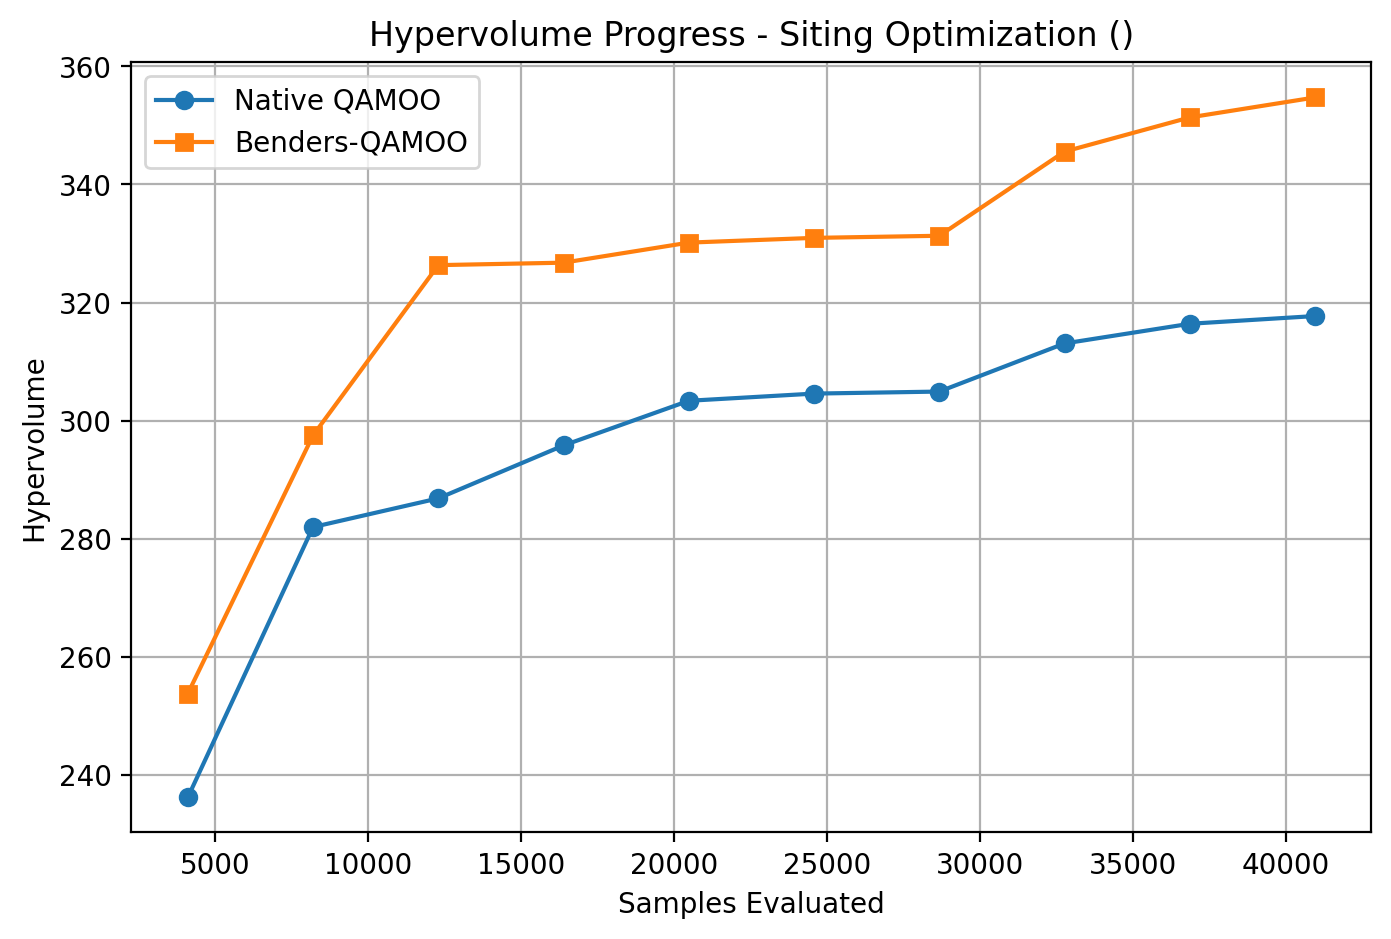

In [16]:
step_size = max(1, config.total_num_samples // 10)
steps = range(0, config.total_num_samples + 1, step_size)

try:
    compute_hypervolume_progress(problem.problem_folder, config.results_folder, steps)
    compute_hypervolume_progress(problem.problem_folder, benders_config.results_folder, steps)

    native_x, native_y = config.progress_x_y()
    benders_x, benders_y = benders_config.progress_x_y()

    print(f"Max Hypervolume (native QAMOO): {max(native_y):.2f}")
    print(f"Max Hypervolume (Benders-QAMOO): {max(benders_y):.2f}")

    plt.figure(figsize=(8, 5))
    plt.plot(native_x, native_y, marker='o', label='Native QAMOO')
    plt.plot(benders_x, benders_y, marker='s', label='Benders-QAMOO')
    plt.title(f'Hypervolume Progress - Siting Optimization ({net.name})')
    plt.xlabel('Samples Evaluated')
    plt.ylabel('Hypervolume')
    plt.grid(True)
    plt.legend()
    plt.show()
except Exception as e:
    print(f"Evaluation encountered an issue: {e}")

## 5. Exact Benchmark (DPA vs CPLEX)
Here we execute a native Python scalarized multi-objective loop using IBM CPLEX (via the `docplex` library) as well as the DPA algorithm. DPA is an external C++ binary that natively solves MOIP (Multi-Objective Integer Programming). We build the QUBO constraint mapping and search the Pareto space using both a weighted-sum scalarization (CPLEX) and epsilon-constraint (DPA) to compare the results.

In [17]:
from docplex.mp.model import Model
from qamoo.utils.utils import pareto_front

def solve_classical_mo_cplex(num_qubits, problem_dir, num_objectives, num_evaluations=50):
    import pickle
    
    qps = []
    for obj in range(num_objectives):
        with open(f"{problem_dir}/problem_qp_{obj}.pkl", 'rb') as f:
            qps.append(pickle.load(f))
            
    np.random.seed(42)
    weights = np.random.dirichlet(np.ones(num_objectives), num_evaluations)
    
    classical_pareto_points = []
    
    for w in weights:
        mdl = Model(name='microgrid_mo')
        x = mdl.binary_var_list(num_qubits, name="x")
        
        # Add budget constraint from all QPs (they share the same constraint;
        # iterating all ensures none are missed)
        seen_constraints = set()
        for qp in qps:
            for cstr in qp.linear_constraints:
                cstr_key = (tuple(sorted(cstr.linear.to_dict().items())), cstr.sense.name, cstr.rhs)
                if cstr_key not in seen_constraints:
                    seen_constraints.add(cstr_key)
                    expr = sum(coef * x[idx] for idx, coef in cstr.linear.to_dict().items())
                    if cstr.sense.name == "LE":
                        mdl.add_constraint(expr <= cstr.rhs)
                    elif cstr.sense.name == "GE":
                        mdl.add_constraint(expr >= cstr.rhs)
                    elif cstr.sense.name == "EQ":
                        mdl.add_constraint(expr == cstr.rhs)
                
        # Build combined objective
        obj_expr = 0
        for idx in range(num_objectives):
            qp = qps[idx]
            sub_obj = qp.objective.constant
            for var_idx, val in qp.objective.linear.to_dict().items():
                sub_obj += val * x[var_idx]
            for (var_idx1, var_idx2), val in qp.objective.quadratic.to_dict().items():
                sub_obj += val * x[var_idx1] * x[var_idx2]
            obj_expr += w[idx] * sub_obj
            
        mdl.minimize(obj_expr)
        mdl.set_time_limit(5)
        mdl.context.solver.log_output = False
        
        sol = mdl.solve()
        if sol:
            vals = [sol.get_value(x[i]) for i in range(num_qubits)]
            f_vals = [qp.objective.evaluate(vals) for qp in qps]
            classical_pareto_points.append(f_vals)
            
    return np.array(classical_pareto_points)

print("Running Classical Exact Benchmark (CPLEX Weighted-Sum)...")
try:
    classical_points = solve_classical_mo_cplex(num_qubits, problem_dir, num_objectives, 30)
    nd_idx = pareto_front(classical_points)
    classical_nd_points = classical_points[nd_idx]
except Exception as e:
    print(f"CPLEX Python API not fully configured. {e}")
    classical_nd_points = []

Running Classical Exact Benchmark (CPLEX Weighted-Sum)...


100%|██████████| 30/30 [00:00<00:00, 34044.68it/s]


In [18]:
import subprocess
import os
import re

def solve_classical_mo_dpa(num_qubits, problem_dir, num_objectives):
    import pickle
    from docplex.mp.model import Model
    
    qps = []
    for obj in range(num_objectives):
        with open(f"{problem_dir}/problem_qp_{obj}.pkl", 'rb') as f:
            qps.append(pickle.load(f))
            
    mdl = Model(name='microgrid_mo_dpa')
    x = mdl.binary_var_list(num_qubits, name="x")
    
    # Collect all quadratic terms
    quad_terms = set()
    for qp in qps:
        for (u, v) in qp.objective.quadratic.to_dict().keys():
            quad_terms.add(tuple(sorted((u, v))))
            
    # McCormick linearization: z[u,v] = x[u] * x[v]
    z = mdl.binary_var_dict(quad_terms, name="z")
    for u, v in quad_terms:
        mdl.add_constraint(z[u, v] <= x[u])
        mdl.add_constraint(z[u, v] <= x[v])
        mdl.add_constraint(z[u, v] >= x[u] + x[v] - 1)
        
    # Add budget constraint
    for cstr in qps[0].linear_constraints:
        expr = sum(coef * x[idx] for idx, coef in cstr.linear.to_dict().items())
        if cstr.sense.name == "LE":
            mdl.add_constraint(expr <= cstr.rhs)
        elif cstr.sense.name == "GE":
            mdl.add_constraint(expr >= cstr.rhs)
        elif cstr.sense.name == "EQ":
            mdl.add_constraint(expr == cstr.rhs)
            
    # Add the objective functions as constraints at the end for DPA
    SCALE_FACTOR = 1000.0
    for idx in range(num_objectives):
        qp = qps[idx]
        obj_expr = qp.objective.constant * SCALE_FACTOR
        for var_idx, val in qp.objective.linear.to_dict().items():
            obj_expr += (val * SCALE_FACTOR) * x[var_idx]
        for (var_idx1, var_idx2), val in qp.objective.quadratic.to_dict().items():
            obj_expr += (val * SCALE_FACTOR) * z[tuple(sorted((var_idx1, var_idx2)))]
            
        if idx == num_objectives - 1:
            mdl.add_constraint(obj_expr <= num_objectives, ctname=f"obj_{idx}")
        else:
            mdl.add_constraint(obj_expr <= 0, ctname=f"obj_{idx}")
            
    mdl.minimize(0)
    lp_path = f"{problem_dir}/dpa_problem.lp"
    mdl.export_as_lp(lp_path)
    
    print("Running DPA Exact Benchmark...")
    dpa_bin = "./dpa-main"
    out_file = f"{problem_dir}/dpa_out"
    cmd = [dpa_bin, lp_path, "-a", out_file, "3600", "empty.txt"]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        raise RuntimeError(f"DPA failed (code {proc.returncode}): {proc.stderr[-500:]}")
        
    sol_file = out_file + ".sol"
    if not os.path.exists(sol_file):
        raise FileNotFoundError(f"DPA solution file not found: {sol_file}")

    num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")
    pareto_points = []
    with open(sol_file, 'r') as f:
        for line in f:
            if line.startswith("---"):
                break
            vals = [float(v) for v in num_re.findall(line)]
            if len(vals) >= num_objectives:
                raw = vals[-num_objectives:]
                pareto_points.append(raw)
                
    pts = np.array(pareto_points, dtype=float) / SCALE_FACTOR
    print(f"DPA parsed points: {pts.shape}")
    if pts.size:
        print("Sample DPA point:", pts[0].tolist())
    return pts

try:
    dpa_points = solve_classical_mo_dpa(num_qubits, problem_dir, num_objectives)
    dpa_nd_idx = pareto_front(dpa_points) if len(dpa_points) > 0 else []
    dpa_nd_points = dpa_points[dpa_nd_idx] if len(dpa_points) > 0 else []
except Exception as e:
    print(f"DPA failed. {e}")
    dpa_nd_points = []

Running DPA Exact Benchmark...
DPA parsed points: (57, 3)
Sample DPA point: [-1.738, 0.5, -2.824]


100%|██████████| 57/57 [00:00<00:00, 21460.98it/s]


## 6. Configuration Visualization
Visualizing the physical grid mapping for a selected optimal microgrid siting solution from the quantum Pareto front using `rustworkx`.

In [19]:
import rustworkx as rx
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# Visualization options
INTERACTIVE_PLOT = False  # Set to False to render a static, HTML-exportable plot of the best compromise solution
USE_BENDERS = False       # Set to True to render Benders-QAMOO Pareto front, False for native QAMOO

try:
    # Determine which results to load
    target_config = benders_config if USE_BENDERS else config
    method_name = "Benders-QAMOO" if USE_BENDERS else "Native QAMOO"

    # Load the quantum non-dominated solutions
    nd_positions = np.load(target_config.results_folder + 'non_dominated_positions.npy')
    all_samples = np.load(target_config.results_folder + 'samples.npy')
    
    if len(nd_positions) > 0:
        # 1. Create rustworkx graph natively
        rx_graph = rx.PyGraph()
        rx_graph.add_nodes_from(range(num_buses))
        rx_graph.add_edges_from_no_data([(u, v) for u, v in edges])
        
        # Calculate static layout coordinates
        pos_dict = rx.spring_layout(rx_graph, seed=42)
        q_pts = np.load(target_config.results_folder + 'non_dominated_samples.npy')

        # Build Edge Coordinates (Static)
        edge_x, edge_y = [], []
        for u, v in edges:
            x0, y0 = pos_dict[u]
            x1, y1 = pos_dict[v]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])

        def get_plot_figure(sol_idx):
            best_config = all_samples[nd_positions[sol_idx]]
            obj_vals = q_pts[sol_idx]
            
            placed_x, placed_y, placed_text = [], [], []
            standard_x, standard_y, standard_text = [], [], []
            nc_x, nc_y, nc_text = [], [], []
            
            for bus in range(num_buses):
                x, y = pos_dict[bus]
                if bus in pruned_buses:
                    idx = pruned_buses.index(bus)
                    if best_config[idx] == 1:
                        placed_x.append(x)
                        placed_y.append(y)
                        placed_text.append(f"Bus {bus}")
                    else:
                        standard_x.append(x)
                        standard_y.append(y)
                        standard_text.append(f"Bus {bus}")
                else:
                    nc_x.append(x)
                    nc_y.append(y)
                    nc_text.append(f"Bus {bus}")

            title_text = (
                f'Siting Plan ({method_name} - Solution {sol_idx+1}/{len(nd_positions)})<br>'
                f'Voltage Dev: {obj_vals[0]:.4f} | Cost: {obj_vals[1]:.4f} | Reliability: {obj_vals[2]:.4f}'
            )

            fig = go.Figure(
                data=[
                    go.Scatter(x=edge_x, y=edge_y, line=dict(width=1.5, color='#888'), hoverinfo='none', mode='lines', name='Edges'),
                    go.Scatter(x=placed_x, y=placed_y, mode='markers+text', text=placed_text, textposition="top center", name='Microgrid/Storage Placed (1)', marker=dict(color='#FF6B6B', size=24)),
                    go.Scatter(x=standard_x, y=standard_y, mode='markers+text', text=standard_text, textposition="top center", name='Standard Bus (0)', marker=dict(color='#4ECDC4', size=24)),
                    go.Scatter(x=nc_x, y=nc_y, mode='markers+text', text=nc_text, textposition="top center", name='Non-candidate Bus', marker=dict(color='#E0E0E0', size=24))
                ],
                layout=go.Layout(
                    title=dict(text=title_text, font=dict(size=14)),
                    showlegend=True,
                    hovermode='closest',
                    margin=dict(b=20, l=5, r=5, t=60),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    width=800, height=600,
                    template="plotly_white"
                )
            )
            return fig

        if INTERACTIVE_PLOT:
            # We construct a FigureWidget and bind it to the slider
            fig = go.FigureWidget(get_plot_figure(len(nd_positions) // 2))
            
            def update_plot_data(sol_idx):
                best_config = all_samples[nd_positions[sol_idx]]
                obj_vals = q_pts[sol_idx]
                
                placed_x, placed_y = [], []
                standard_x, standard_y = [], []
                nc_x, nc_y = [], []
                
                for bus in range(num_buses):
                    x, y = pos_dict[bus]
                    if bus in pruned_buses:
                        idx = pruned_buses.index(bus)
                        if best_config[idx] == 1:
                            placed_x.append(x)
                            placed_y.append(y)
                        else:
                            standard_x.append(x)
                            standard_y.append(y)
                    else:
                        nc_x.append(x)
                        nc_y.append(y)
                
                with fig.batch_update():
                    fig.data[1].x = placed_x
                    fig.data[1].y = placed_y
                    fig.data[2].x = standard_x
                    fig.data[2].y = standard_y
                    fig.data[3].x = nc_x
                    fig.data[3].y = nc_y
                    fig.layout.title.text = (
                        f'Siting Plan ({method_name} - Solution {sol_idx+1}/{len(nd_positions)})<br>'
                        f'Voltage Dev: {obj_vals[0]:.4f} | Cost: {obj_vals[1]:.4f} | Reliability: {obj_vals[2]:.4f}'
                    )

            slider = widgets.IntSlider(
                min=0, max=len(nd_positions)-1, step=1, 
                value=len(nd_positions)//2, 
                description='Pareto Index'
            )
            
            def on_slider_change(change):
                update_plot_data(change['new'])
                    
            slider.observe(on_slider_change, names='value')
            layout_box = widgets.VBox([slider, fig])
            display(layout_box)
        else:
            # Render the best compromise solution on the quantum Pareto front
            # We select the compromise solution that minimizes the normalized L2 distance to the ideal point.
            if len(nd_positions) > 1:
                # Find ideal point (min values in each objective)
                ideal = q_pts.min(axis=0)
                nadir = q_pts.max(axis=0)
                ranges = nadir - ideal
                ranges[ranges == 0] = 1e-6
                
                # Compute L2 distance from normalized objectives to ideal (0)
                norm_pts = (q_pts - ideal) / ranges
                best_sol_idx = int(np.argmin(np.linalg.norm(norm_pts, axis=1)))
            else:
                best_sol_idx = 0
                
            fig = get_plot_figure(best_sol_idx)
            fig.layout.title.text += "<br><b>Best Compromise Solution (L2 ideal-compromise on Pareto front)</b>"
            fig.show()
            
    else:
        print("No non-dominated solutions found to visualize.")
except Exception as e:
    print(f"Could not render visualization. Error: {e}")

![](qamoo_plot.png)

## 7. Multi-Metric Pareto Quality Analysis
For a comprehensive analysis, we tabulate some multi-objective indicators from the optimization literature:

- **|PF|**: Size of the Pareto Front (number of non-dominated points).
- **Hypervolume (HV)**: The volume of the objective space dominated by a Pareto set w.r.t. a reference point (higher is better).
- **IGD** (Inverted Generational Distance): The average distance from the reference (exact union) set to the nearest points in the evaluated set (lower is better).
- **Spacing**: A measure of the spread/uniformity of points along the front (lower is better). If the front has only 1 point, there is no spread, so this is undefined (`N/A`).
- **Additive Epsilon Indicator** ($\epsilon^+$): The minimum additive shift required for the evaluated front to weakly dominate the reference (exact union) front (lower is better).
- **Coverage** $C(A,B)$: The fraction of points in $B$ dominated by at least one point in $A$ (higher is better).
  - **C(A,B)**: The fraction of the exact reference union dominated by the method's front.
  - **C(B,A)**: The fraction of the method's front dominated by the exact reference union.
  - *Note*: $C(A, B)$ is asymmetric because it measures how well set $A$ covers/dominates set $B$. If $A$ is high-quality (e.g. exact union) and $B$ is low-quality, $C(A, B)$ is high while $C(B, A)$ is $0.0$.

We treat CPLEX and DPA outputs as the **exact reference union** when available.

In [20]:
# Additional Pareto-quality metrics for clearer method comparison
from pymoo.indicators.hv import HV
from IPython.display import display
import numpy as np
import pandas as pd
import os

def _as_points(a, m):
    a = np.asarray(a, dtype=float)
    if a.size == 0:
        return np.empty((0, m), dtype=float)
    return a.reshape(-1, m)

def _to_min(points_max):
    # Our objectives are already formulated in minimization space.
    return points_max

def _dominates_min(a, b):
    return np.all(a <= b) and np.any(a < b)

def coverage_c_metric(A_min, B_min):
    # Fraction of B dominated by at least one point in A (minimization).
    if len(B_min) == 0:
        return np.nan
    if len(A_min) == 0:
        return 0.0
    dominated = 0
    for b in B_min:
        if any(_dominates_min(a, b) or np.allclose(a, b) for a in A_min):
            dominated += 1
    return dominated / len(B_min)

def additive_epsilon_indicator(A_min, B_min):
    # epsilon^+(A,B) = max_{b in B} min_{a in A} max_i (a_i - b_i)
    if len(A_min) == 0 or len(B_min) == 0:
        return np.nan
    eps_vals = []
    for b in B_min:
        eps_b = min(np.max(a - b) for a in A_min)
        eps_vals.append(eps_b)
    return float(np.max(eps_vals))

def spacing_metric(S_min):
    # Deb spacing-like metric with L1 nearest-neighbor distances.
    if len(S_min) <= 1:
        return np.nan
    d = []
    for i in range(len(S_min)):
        dist = np.sum(np.abs(S_min - S_min[i]), axis=1)
        dist[i] = np.inf
        d.append(np.min(dist))
    d = np.asarray(d, dtype=float)
    return float(np.sqrt(np.mean((d - np.mean(d)) ** 2)))

def igd_metric(approx_min, ref_min):
    # Mean distance from each reference point to nearest approximate point.
    if len(ref_min) == 0 or len(approx_min) == 0:
        return np.nan
    d = []
    for r in ref_min:
        d.append(np.min(np.linalg.norm(approx_min - r, axis=1)))
    return float(np.mean(d))

def _try_load_quantum_points(results_folder, m):
    # Best-effort loader to support different QAMOO output file names.
    candidates = [
        "non_dominated_points.npy",
        "non_dominated_objective_values.npy",
        "pareto_points.npy",
        "non_dominated_samples.npy",
    ]
    for fn in candidates:
        p = os.path.join(results_folder, fn)
        if os.path.exists(p):
            return _as_points(np.load(p), m)

    # Fallback: objective values + non-dominated indices
    vals_p = os.path.join(results_folder, "objective_values.npy")
    nd_p = os.path.join(results_folder, "non_dominated_positions.npy")
    if os.path.exists(vals_p) and os.path.exists(nd_p):
        vals = _as_points(np.load(vals_p), m)
        idx = np.asarray(np.load(nd_p), dtype=int).ravel()
        idx = idx[(idx >= 0) & (idx < len(vals))]
        if len(idx):
            return vals[idx]
    return np.empty((0, m), dtype=float)

# Existing fronts from previous sections
cplex_pts = _as_points(classical_nd_points, num_objectives)
dpa_pts = _as_points(dpa_nd_points, num_objectives)
q_pts = _try_load_quantum_points(config.results_folder, num_objectives)
benders_q_pts = _try_load_quantum_points(benders_config.results_folder, num_objectives)

# Convert to minimization space for standard indicators
cplex_min = _to_min(cplex_pts)
dpa_min = _to_min(dpa_pts)
q_min = _to_min(q_pts)
benders_q_min = _to_min(benders_q_pts)

# Exact reference: union of exact methods when available
exact_union_min = np.vstack([p for p in [cplex_min, dpa_min] if len(p)]) if (len(cplex_min) or len(dpa_min)) else np.empty((0, num_objectives))

# HV reference point from all available methods to keep scale comparable
all_min = np.vstack([p for p in [q_min, benders_q_min, cplex_min, dpa_min] if len(p)]) if (len(q_min) or len(benders_q_min) or len(cplex_min) or len(dpa_min)) else np.empty((0, num_objectives))
ref_point = np.max(all_min, axis=0) + 1e-6 if len(all_min) else np.ones(num_objectives)
hv = HV(ref_point=ref_point)

methods = [
    ("QAMOO (Quantum)", q_min),
    ("Benders-QAMOO (Quantum)", benders_q_min),
    ("CPLEX (Exact Classical WS)", cplex_min),
    ("DPA (Exact Classical)", dpa_min),
]

rows = []
for name, pts in methods:
    rows.append([
        name,
        int(len(pts)),
        float(hv(pts)) if len(pts) else 0.0,
        igd_metric(pts, exact_union_min),
        spacing_metric(pts),
        additive_epsilon_indicator(pts, exact_union_min),
        coverage_c_metric(pts, exact_union_min),
        coverage_c_metric(exact_union_min, pts),
    ])

# MultiIndex columns to group the Coverage C(A,B) and C(B,A) subcolumns at the end of the table
columns = pd.MultiIndex.from_tuples([
    ("Method", ""),
    ("|PF|", ""),
    ("HV (higher better)", ""),
    ("IGD to exact union (lower better)", ""),
    ("Spacing (lower better)", ""),
    ("eps+ (method, exact)", ""),
    ("Coverage", "C(A,B)"),
    ("Coverage", "C(B,A)"),
])

df_metrics = pd.DataFrame(rows, columns=columns)

# Pretty display
df_view = df_metrics.copy()
for c in [
    ("HV (higher better)", ""),
    ("IGD to exact union (lower better)", ""),
    ("Spacing (lower better)", ""),
    ("eps+ (method, exact)", ""),
    ("Coverage", "C(A,B)"),
    ("Coverage", "C(B,A)"),
]:
    df_view[c] = df_view[c].map(lambda v: "N/A" if pd.isna(v) else f"{v:,.4f}")

styled = (
    df_view.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center", "padding": "8px", "font-size": "11pt"})
    .set_table_styles([
        {"selector": "th", "props": "text-align:center; font-size:11pt; font-weight:bold; background-color:#eef4fb;"},
        {"selector": "td", "props": "border:1px solid #dddddd;"},
        {"selector": "table", "props": "border-collapse:collapse; width:100%;"},
    ])
    .set_caption("Pareto Quality Metrics (with exact-union reference)")
)

print("\n=== Multi-Metric Pareto Quality Summary ===")
print(f"QAMOO points: {len(q_pts)}, Benders-QAMOO points: {len(benders_q_pts)}, CPLEX points: {len(cplex_pts)}, DPA points: {len(dpa_pts)}")
if len(dpa_pts) == 0:
    print("Note: DPA points are empty, so DPA metrics will be degenerate (HV=0 and many N/A).")
display(styled)


=== Multi-Metric Pareto Quality Summary ===
QAMOO points: 189, Benders-QAMOO points: 270, CPLEX points: 9, DPA points: 57
